In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

df=pd.read_csv('/content/drive/MyDrive/disease prediction/diabetes.csv')
print("head:",df.head())
print("shape:",df.shape)
print("cols:",df.columns)
print("info:",df.info)
print("missing values",df.isnull().sum())

head:    Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0           0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1           0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2           0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3           0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4           0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0      18.0      15.0       1.0  0.0   9.0        4.0   


In [ ]:
print("ranges:",df.describe)

ranges: <bound method NDFrame.describe of         Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0                0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1                0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2                0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3                0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4                0.0     1.0       1.0        1.0  24.0     0.0     0.0   
...              ...     ...       ...        ...   ...     ...     ...   
253675           0.0     1.0       1.0        1.0  45.0     0.0     0.0   
253676           2.0     1.0       1.0        1.0  18.0     0.0     0.0   
253677           0.0     0.0       0.0        1.0  28.0     0.0     0.0   
253678           0.0     1.0       0.0        1.0  23.0     0.0     0.0   
253679           2.0     1.0       1.0        1.0  25.0     0.0     0.0   

        HeartDiseaseorAttack  PhysActivity  Fruits  ...  

In [ ]:

#here we understand the number of people without diabetes-0
#people pre diabetic-1
#people with diabetes-2
print("count of people with diabetes",df["Diabetes_012"].value_counts())

count of people with diabetes Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64


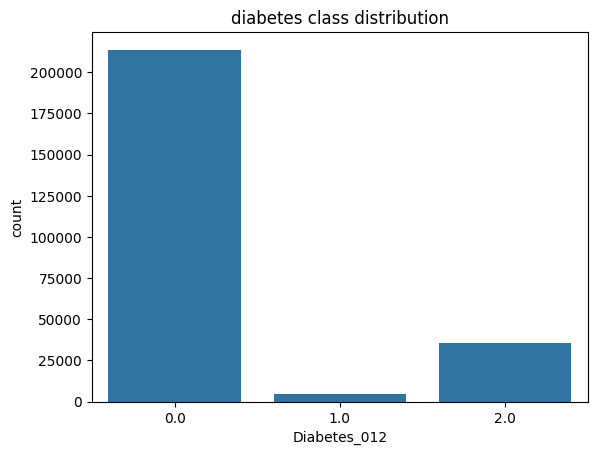

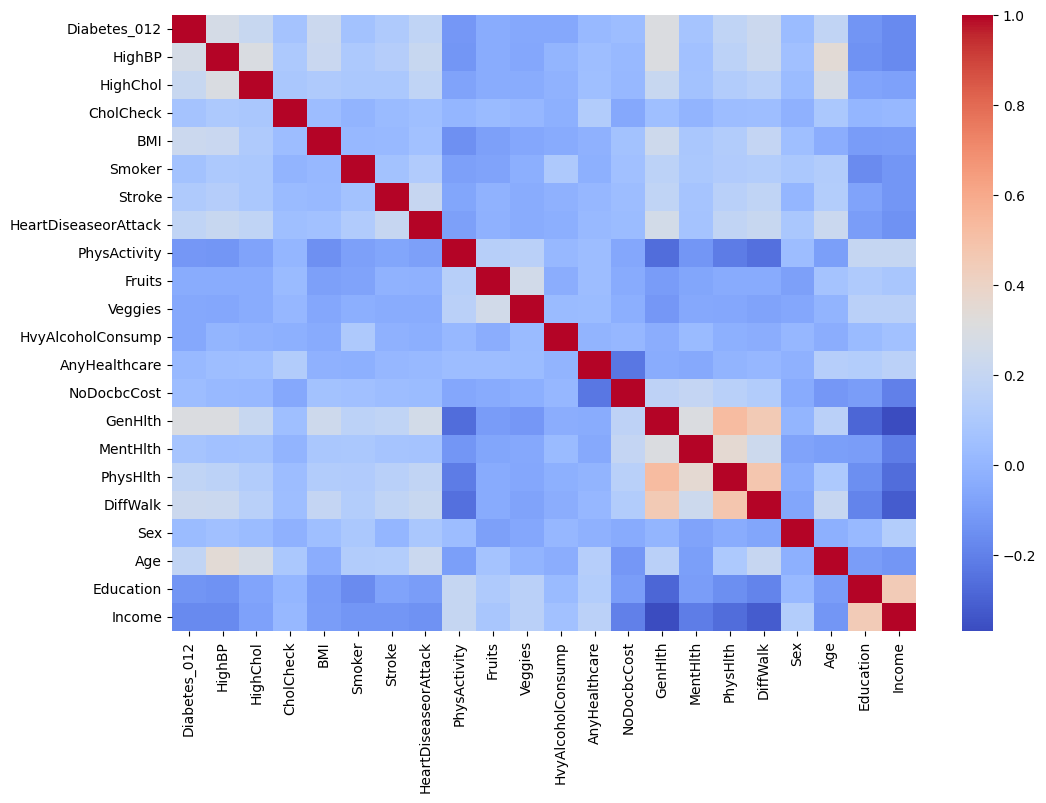

In [ ]:
#plotting the 3 conditions to see the distribution of people
#next is the heatt map for all the diffrent features considered like the age,gender etc

sns.countplot(x="Diabetes_012",data=df)
plt.title("diabetes class distribution")
plt.show()

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()

Accuracy: 0.815357931251971
classification report:               precision    recall  f1-score   support

           0       0.89      0.89      0.89     42741
           1       0.42      0.44      0.43      7995

    accuracy                           0.82     50736
   macro avg       0.66      0.66      0.66     50736
weighted avg       0.82      0.82      0.82     50736



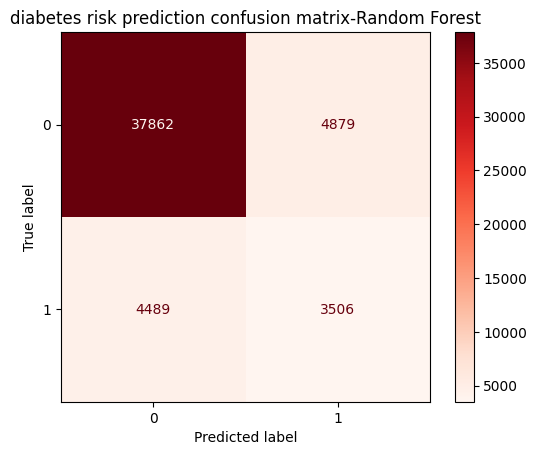

In [22]:
# Data Processing
import pandas as pd
import numpy as np

# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay,classification_report,f1_score
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint

# Tree Visualisation
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

df=pd.read_csv('/content/drive/MyDrive/disease prediction/diabetes.csv')

df["Diabetes_binary"]=df["Diabetes_012"].apply(lambda x:0 if x==0 else 1)
y=df["Diabetes_binary"]

x=df.drop(["Diabetes_012","Diabetes_binary"],axis=1)

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    max_depth=20,
    random_state=42
)
rf.fit(x_train, y_train)

y_pred = rf.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("classification report:",classification_report(y_test,y_pred))
a=confusion_matrix(y_test,y_pred)
sh=ConfusionMatrixDisplay(confusion_matrix=a)

#storing this data for model comparison
rf_accuracy = accuracy_score(y_test, y_pred)
rf_precision = precision_score(y_test, y_pred)
rf_recall = recall_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
sh.plot(cmap="Reds")

plt.title("diabetes risk prediction confusion matrix-Random Forest")
plt.show()

Accuracy: 0.8323741196257752
classification report:               precision    recall  f1-score   support

           0       0.90      0.90      0.90     64111
           1       0.47      0.47      0.47     11993

    accuracy                           0.83     76104
   macro avg       0.68      0.68      0.68     76104
weighted avg       0.83      0.83      0.83     76104



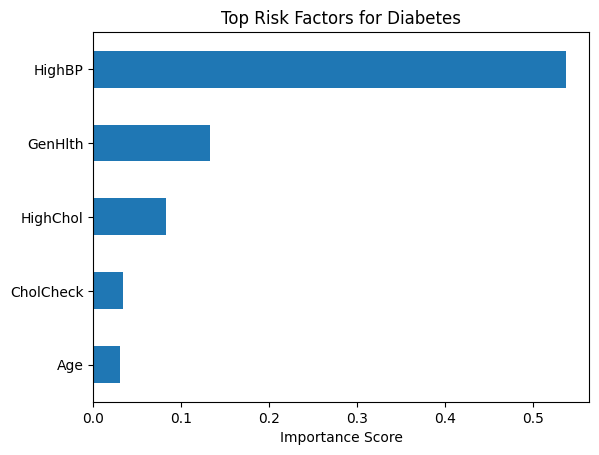

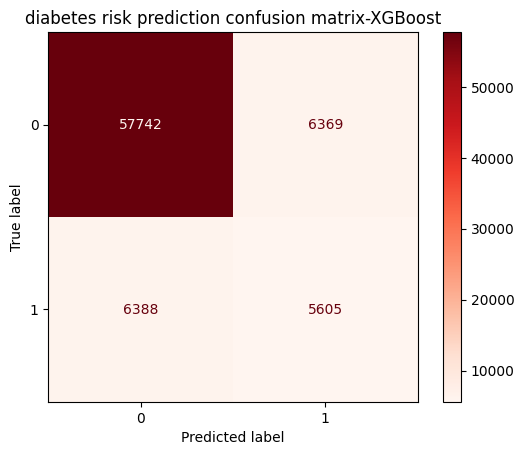

['feature_list.pkl']

In [39]:
from xgboost import XGBClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

df=pd.read_csv('/content/drive/MyDrive/disease prediction/diabetes.csv')

df["Diabetes_binary"]=df["Diabetes_012"].apply(lambda x:0 if x==0 else 1)
y=df["Diabetes_binary"]

x=df.drop(["Diabetes_012","Diabetes_binary"],axis=1)

# Split data
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3 ,stratify=y,random_state=42)

scale_pos_weight =2  #len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# xgboost model
model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)
model.fit(X_train, y_train)

# Prediction part
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("classification report:",classification_report(y_test,y_pred))


#to find the top risk factors aka features
importance = pd.Series(model.feature_importances_, index=x.columns)
importance.sort_values(ascending=True).tail(5).plot(kind="barh")

plt.title("Top Risk Factors for Diabetes")
plt.xlabel("Importance Score")
plt.show()

#confusion matrix data

m=confusion_matrix(y_test,y_pred)
sho=ConfusionMatrixDisplay(confusion_matrix=m)

sho.plot(cmap="Reds")

#storing the values for model comparison
xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_precision = precision_score(y_test, y_pred)
xgb_recall = recall_score(y_test, y_pred)
xgb_f1 = f1_score(y_test, y_pred)

plt.title("diabetes risk prediction confusion matrix-XGBoost")
plt.show()

joblib.dump(model,"diabetes_xgboost_model.pkl")

#to save the features required later when taking user input
joblib.dump(x.columns.tolist(),"feature_list.pkl")


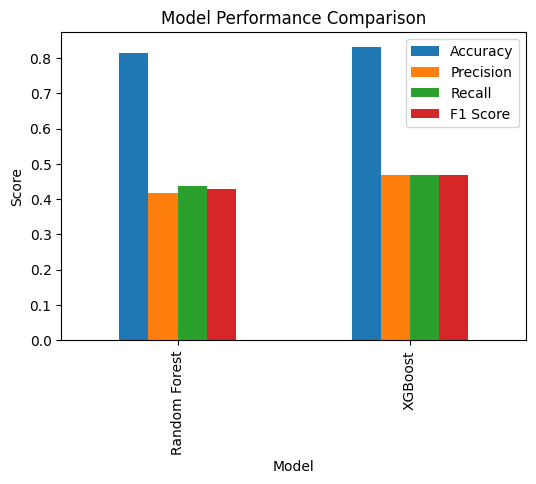

In [33]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [rf_accuracy, xgb_accuracy],
    "Precision": [rf_precision, xgb_precision],
    "Recall": [rf_recall, xgb_recall],
    "F1 Score": [rf_f1, xgb_f1]
})

comparison

comparison.set_index("Model").plot(kind="bar", figsize=(6,4))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.show()